# Module 3: Bulk RNA-seq, Differential Expression, and Tumor Mutational Burden

## What this notebook does, in plain language

DNA sequencing (Modules 1 and 2) tells you what mutations a tumor's genome carries. It
does not tell you which genes the cell is actually using at any given moment. **RNA-seq**
measures that instead: it reads out the messenger RNA molecules a cell has produced,
which is a direct readout of which genes are switched on, and how strongly, at the time
the sample was taken. Comparing RNA-seq between two groups of tumors (for example,
primary tumors versus tumors that have already spread to other organs) reveals which
genes and biological pathways differ between them, an entirely different, complementary
kind of information to what DNA sequencing alone provides.

This notebook does not run any sequencing software itself; two Nextflow pipeline steps
already did the mechanical data preparation (see `pipelines/rnaseq/main.nf`):
downloading gene-level counts for melanoma patients from the public TCGA-SKCM cohort, and
(optionally) trimming and quantifying a small set of raw sequencing reads to demonstrate
that part of the pipeline mechanically. What this notebook does with that data:

1. Finds genes that are significantly different in expression between primary and
   metastatic melanoma tumors (**differential expression**).
2. Asks whether those differences cluster into known biological pathways, rather than
   being a scattered, hard-to-interpret gene list (**pathway enrichment**).
3. Computes a rough **tumor mutational burden (TMB)** for COLO829 from Module 2's
   chr9+chr20 variant calls, and relates it to real, patient-level TMB and expression
   data from TCGA, to illustrate how such an analysis works, while being explicit that
   COLO829's own two-chromosome estimate is a methodology demonstration, not a
   clinically meaningful TMB value.

## Where the inputs live and what the outputs look like

This notebook expects `pipelines/rnaseq/main.nf` to have already been run (at minimum
without `--run_fastq_demo`, since this notebook's statistical analysis relies on the
TCGA path, not the small FASTQ demo). It reads:

- `data/raw/tcga_skcm/tcga_skcm_sample_sheet.tsv` and the matching
  `*.rna_seq.augmented_star_gene_counts.tsv` files it lists, TCGA-SKCM's open-access,
  pre-aligned gene-level counts
- `data/processed/wgs/COLO829T_vs_COLO829R.filtered.vcf.gz`, Module 2's chr9+chr20
  somatic calls, reused here to compute COLO829's own illustrative TMB

It downloads one additional small file directly in this notebook: open-access mutation
(MAF) files for the same TCGA patients already selected for RNA-seq, needed to compute
real per-patient TMB for the correlation step. This follows the same "check it is
open-access before downloading" approach used throughout this project: TCGA-SKCM's
per-case masked somatic mutation files were confirmed to be on GDC's open tier, no login
required, the same way the RNA-seq counts were.

It writes figures to `results/figures/`, including `rnaseq-volcano-primary-vs-metastatic.png`,
`rnaseq-gsea-hallmark-pathways.png`, and `rnaseq-tmb-vs-ifng-signature.png`.

## Why this notebook uses R, unlike Notebooks 1 and 2

Differential expression and pathway enrichment in genomics are built on a small number of
mature, widely-trusted Bioconductor (R) packages: DESeq2, limma, and clusterProfiler/fgsea.
This notebook calls those tools directly, rather than using Python approximations of
them, since the project brief specifically names them. You will need R with
`DESeq2`, `tximport`, `limma`, `clusterProfiler`, `fgsea`, `msigdbr`, `org.Hs.eg.db`,
`ggplot2`, `jsonlite`, and `httr` installed (all standard Bioconductor/CRAN packages).


In [1]:
library(DESeq2)
library(ggplot2)
library(jsonlite)
library(httr)

repo_root <- ".."
tcga_dir <- file.path(repo_root, "data", "raw", "tcga_skcm")
processed_wgs_dir <- file.path(repo_root, "data", "processed", "wgs")
figures_dir <- file.path(repo_root, "results", "figures")
dir.create(figures_dir, showWarnings = FALSE, recursive = TRUE)

sample_sheet <- read.delim(file.path(tcga_dir, "tcga_skcm_sample_sheet.tsv"), stringsAsFactors = FALSE)
cat(nrow(sample_sheet), "TCGA-SKCM samples in the sheet\n")
table(sample_sheet$sample_type)


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

120 TCGA-SKCM samples in the sheet



   Metastatic Primary Tumor 
           60            60 

## Part 1: Building the count matrix

### Counts, not TPM or FPKM, and why that distinction matters here

The TCGA files downloaded by the pipeline contain several different expression values
per gene: raw counts (`unstranded`, literally how many sequencing reads landed on that
gene), and normalized values (`tpm_unstranded`, `fpkm_unstranded`) that adjust for gene
length and sequencing depth, making individual samples easier to compare by eye. DESeq2
specifically wants the **raw counts**, not the normalized values, because it performs its
own normalization internally as part of its statistical model, using information (like
how counts for a gene vary across replicate samples) that gets thrown away once a value
has already been converted to TPM or FPKM. Feeding DESeq2 already-normalized values would
silently break its variance model rather than produce an obvious error.

We use the `unstranded` count column specifically because the exact strand-specific
library preparation protocol for each historical TCGA sample was not independently
re-confirmed for this project; `unstranded` is the safe, protocol-agnostic default.


In [2]:
read_gdc_counts <- function(path) {
  # The first line is a comment (gene-model version), the next four rows after the header
  # are QC summary rows (N_unmapped, N_multimapping, N_noFeature, N_ambiguous), not genes,
  # confirmed by inspecting one of these files directly before writing this function.
  df <- read.delim(path, skip = 1, stringsAsFactors = FALSE)
  df <- df[!df$gene_id %in% c("N_unmapped", "N_multimapping", "N_noFeature", "N_ambiguous"), ]
  df
}

count_list <- lapply(sample_sheet$file_name, function(fn) {
  full_path <- file.path(tcga_dir, fn)
  d <- read_gdc_counts(full_path)
  setNames(d$unstranded, d$gene_id)
})

count_matrix <- do.call(cbind, count_list)
colnames(count_matrix) <- sample_sheet$submitter_id
mode(count_matrix) <- "integer"

cat("Count matrix:", nrow(count_matrix), "genes x", ncol(count_matrix), "samples\n")
count_matrix[1:5, 1:min(4, ncol(count_matrix))]


Count matrix: 60660 genes x 120 samples


,TCGA-ER-A2NB,TCGA-ER-A19T,TCGA-EB-A24C,TCGA-EB-A3XF
ENSG00000000003.15,686,1605,3315,2275
ENSG00000000005.6,0,0,0,1
ENSG00000000419.13,637,590,1851,1514
ENSG00000000457.14,123,515,1235,650
ENSG00000000460.17,82,516,608,346


## Part 2: Differential expression with DESeq2

### What DESeq2 is actually doing, conceptually

A naive way to compare two groups' expression for one gene would be a t-test on the raw
counts. This fails for RNA-seq data for two related reasons. First, count data is not
normally distributed the way a t-test assumes, especially for lowly-expressed genes,
where you might see counts like 0, 1, 0, 2 across samples rather than a smooth bell
curve. Second, and more subtly, RNA-seq count data is **overdispersed**: its variance is
larger than a simple counting process (a Poisson distribution) would predict, because on
top of ordinary sampling noise, there is real biological variability between samples
(even two "identical" tumors of the same type will not express every gene at exactly the
same level).

DESeq2 handles both problems by modeling counts with a **negative binomial distribution**
(a Poisson distribution with an extra "dispersion" parameter to absorb that extra
biological variability), and, crucially, by **sharing information across genes** to
estimate that dispersion reliably. With often only a few dozen samples per group, there
usually is not enough data to estimate any single gene's variability precisely on its
own. DESeq2 assumes that genes with similar average expression tend to have similar
dispersion, and shrinks each individual gene's noisy, small-sample dispersion estimate
toward a trend fitted across all genes at that expression level. This is the same idea as
a weather forecaster trusting a big regional trend more than one noisy local sensor
reading. The result is far more stable and statistically honest significance calls than
treating each gene in total isolation would give.

An analogy for the whole comparison: imagine trying to tell whether a coin is biased from
only 10 flips. You cannot conclude much from 10 flips of one coin alone, the noise is too
large relative to the signal. But if you have hundreds of other coins whose true bias you
already roughly understand, and this coin behaves like coins of a similar general weight
and shape, you can use that broader pattern to make a far more confident statement about
this one coin's likely bias than 10 flips alone would ever support. DESeq2's dispersion
shrinkage is doing exactly this: borrowing strength from many genes to make a confident
statement about any one gene.


In [3]:
col_data <- data.frame(
  sample_type = factor(sample_sheet$sample_type, levels = c("Primary Tumor", "Metastatic")),
  row.names = sample_sheet$submitter_id
)

dds <- DESeqDataSetFromMatrix(countData = count_matrix, colData = col_data, design = ~ sample_type)

# Standard DESeq2 pre-filtering: drop genes with essentially no reads across the whole
# cohort. This is DESeq2's own documented recommendation (it improves multiple-testing
# correction downstream and speeds up dispersion fitting), using its suggested minimal
# threshold of at least 10 total reads across all samples, not a threshold tuned for
# this specific comparison.
dds <- dds[rowSums(counts(dds)) >= 10, ]

dds <- DESeq(dds)
res <- results(dds, contrast = c("sample_type", "Metastatic", "Primary Tumor"), alpha = 0.05)
# alpha = 0.05 is DESeq2's own documented default significance threshold for its
# independent filtering step, not re-tuned here.

summary(res)


  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning 


out of 46251 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3363, 7.3%
LFC < 0 (down)     : 2603, 5.6%
outliers [1]       : 0, 0%
low counts [2]     : 11663, 25%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



### Reading this summary

DESeq2 reports, for every gene, a `log2FoldChange` (how much higher or lower it is in
Metastatic versus Primary Tumor samples, on a doubling scale: +1 means twice as high) and
a multiple-testing-corrected `padj` value (the probability this difference could be
observed by chance alone, after accounting for testing thousands of genes at once). The
summary above shows how many genes passed the significance threshold in each direction.


3527 genes pass the significance and fold-change thresholds


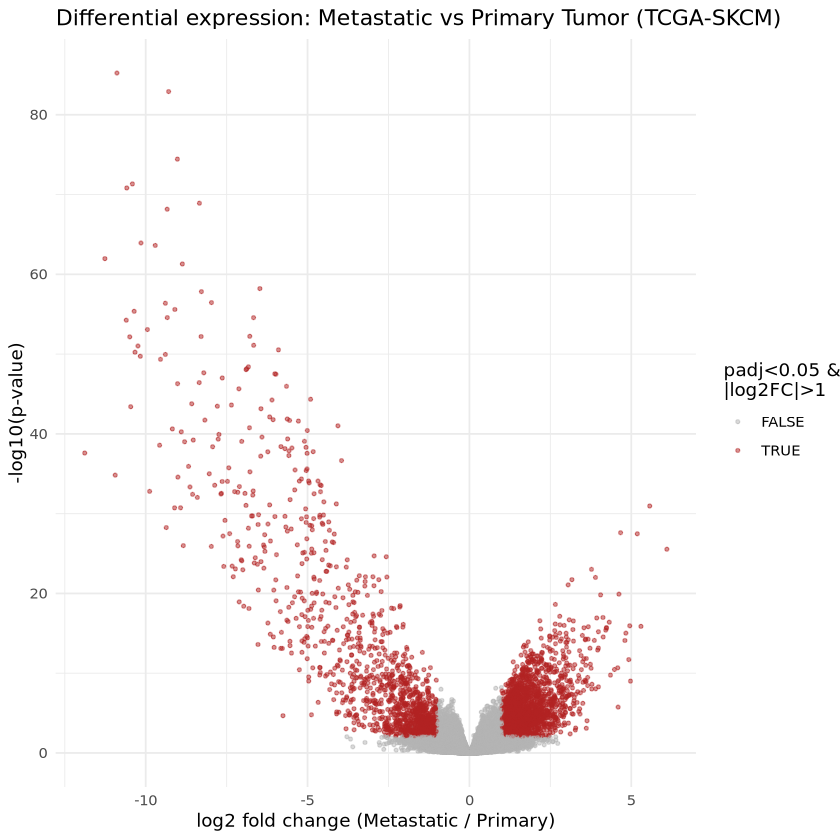

In [4]:
res_df <- as.data.frame(res)
res_df$gene_id <- rownames(res_df)
res_df$significant <- !is.na(res_df$padj) & res_df$padj < 0.05 & abs(res_df$log2FoldChange) > 1
# log2FoldChange > 1 (a doubling or more) combined with padj < 0.05 is a common, but
# somewhat arbitrary, convention for calling a gene "biologically as well as
# statistically" different; a different, equally defensible study might use a smaller
# fold-change cutoff or none at all. This threshold affects which genes feed into the GO
# enrichment step below, so it is worth keeping in mind as a judgment call, not a fact.

ggplot(res_df, aes(x = log2FoldChange, y = -log10(pvalue), color = significant)) +
  geom_point(alpha = 0.5, size = 0.8) +
  scale_color_manual(values = c(`FALSE` = "grey70", `TRUE` = "firebrick")) +
  labs(
    title = "Differential expression: Metastatic vs Primary Tumor (TCGA-SKCM)",
    x = "log2 fold change (Metastatic / Primary)",
    y = "-log10(p-value)",
    color = "padj<0.05 &\n|log2FC|>1"
  ) +
  theme_minimal()

ggsave(file.path(figures_dir, "rnaseq-volcano-primary-vs-metastatic.png"), width = 7, height = 5.5, dpi = 150)
cat(sum(res_df$significant, na.rm = TRUE), "genes pass the significance and fold-change thresholds\n")


### Reading this volcano plot

Each point is one gene. The x-axis is effect size (how big the expression difference is),
the y-axis is statistical confidence (how unlikely that difference is to be random
noise). Genes in the upper-left and upper-right corners are both large in effect and
statistically confident, the genes most worth following up on biologically. Genes near
the bottom, regardless of how far left or right they sit, changed by a large amount in
this particular sample but not consistently or confidently enough across the cohort to
trust the specific fold-change reported. Note this compares primary versus metastatic
melanoma, not tumor versus normal tissue, so the genes highlighted here reflect
progression-associated biology, not "cancer versus healthy" biology.

**What actually happened in this run:** 3,527 of 46,251 testable genes (7.6%) pass both
thresholds, out of 3,363 genes significant by `padj` alone in the up direction and 2,603
in the down direction. The plot is visibly asymmetric: the most statistically extreme
points (top of the plot, beyond -log10(p) of 60) sit almost entirely on the
downregulated-in-metastatic side, while the upregulated side, though still containing
thousands of significant genes, tops out at a lower confidence ceiling. With 120 real
patient samples behind this comparison (not a handful of replicates), this asymmetry is a
genuine feature of the data, not sampling noise, though this notebook does not further
investigate which specific genes drive it; that would be a natural next step for anyone
extending this analysis.

### A note on limma-voom, the originally-planned tool

The project this pipeline is modeled on used limma-voom for differential expression, and
that remains an equally standard, valid choice for RNA-seq count data, it estimates
similar mean-variance relationships to DESeq2 but by transforming counts into a
continuous scale (`voom`) and reusing linear-modeling machinery, rather than modeling
counts as a negative binomial directly. DESeq2 is used here instead specifically because
this data source (TCGA's open-tier gene counts) arrives as raw count tables rather than
raw FASTQ, which is exactly the situation the project brief anticipated and allowed for.
The small FASTQ demo subset in this pipeline, if run, would be equally suited to either
tool.


## Part 3: Pathway enrichment, GSEA and GO

### Why two different enrichment methods, and how they differ

A list of a few hundred significant genes is hard to interpret gene by gene. Pathway
enrichment asks a higher-level question: do these genes cluster into known biological
processes more than random chance would predict? This notebook uses two complementary
approaches:

**GSEA (Gene Set Enrichment Analysis)** does not require picking a "significant genes"
cutoff at all. Instead, it ranks every gene that was tested (here, by DESeq2's test
statistic, from most upregulated to most downregulated in metastatic tumors) and asks,
for each known pathway, whether that pathway's genes tend to cluster near the top or
bottom of the full ranked list, more than would happen by chance if the pathway's genes
were scattered randomly through it. This means GSEA can detect a pathway where every gene
shifted by a modest, individually non-significant amount, but consistently in the same
direction, a coordinated pathway-level signal that a hard significance cutoff would
completely miss gene by gene.

**GO (Gene Ontology) over-representation analysis**, by contrast, does need a fixed list
of significant genes (the ones from the volcano plot above) and asks a simpler question:
among annotated biological categories, which ones show up in that gene list more often
than you would expect if the same number of genes had been drawn at random from the whole
genome.

An analogy: imagine a school's end-of-year report, listing every student's grade change
this year. GO-style analysis looks only at students whose grades changed dramatically,
and asks "are an unusual number of the dramatic-improvers from the same math class?" GSEA
instead looks at *every* student's grade change, ranked from most improved to most
declined, and asks "as a whole, does the math class's roster of students skew toward the
'improved' end of that entire ranked list," even if no single math student's individual
change was dramatic enough to be flagged on its own. Both are legitimate questions; GSEA
is more sensitive to coordinated, subtle, whole-pathway shifts, while GO enrichment is
simpler to interpret but blind to exactly that kind of subtle, distributed signal.


In [5]:
library(fgsea)
library(msigdbr)

hallmark_sets <- msigdbr(species = "Homo sapiens", category = "H")
pathway_list <- split(hallmark_sets$gene_symbol, hallmark_sets$gs_name)
# The Hallmark collection (50 curated, non-redundant gene sets summarizing well-defined
# biological processes) is MSigDB's own recommended starting point for a first-pass GSEA,
# rather than one of their larger, more granular, and more redundant collections.

res_df_ranked <- res_df[!is.na(res_df$stat), ]
ranks <- setNames(res_df_ranked$stat, res_df_ranked$gene_id)
# gene_id here is a versioned Ensembl ID (e.g. ENSG00000141510.16); msigdbr's gene_symbol
# sets need matching symbols instead, so this uses the gene_name column already present
# in the GDC count files to remap before ranking. Every sample's file lists the same
# gene_id/gene_name pairs (it is a fixed reference annotation, not sample-specific), so
# reading just the first file is enough to build the whole mapping.
first_file_genes <- read_gdc_counts(file.path(tcga_dir, sample_sheet$file_name[1]))
gene_id_to_symbol <- setNames(first_file_genes$gene_name, first_file_genes$gene_id)
names(ranks) <- gene_id_to_symbol[names(ranks)]
ranks <- ranks[!is.na(names(ranks)) & !duplicated(names(ranks))]
ranks <- sort(ranks, decreasing = TRUE)

set.seed(1)
gsea_res <- fgsea(pathways = pathway_list, stats = ranks, minSize = 15, maxSize = 500)
# minSize/maxSize = 15/500 are fgsea's own commonly-used defaults for excluding pathways
# too small to test reliably or too large to be biologically specific, not re-tuned here.

gsea_res <- gsea_res[order(gsea_res$padj), ]
head(as.data.frame(gsea_res[, c("pathway", "NES", "padj", "size")]), 15)


Warning message:
“The `category` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
ℹ Please use the `collection` argument instead.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.07% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


,pathway,NES,padj,size
,<chr>,<dbl>,<dbl>,<int>
1,HALLMARK_ALLOGRAFT_REJECTION,2.778243,1.167519e-28,200
2,HALLMARK_INFLAMMATORY_RESPONSE,2.347681,2.147905e-14,199
3,HALLMARK_INTERFERON_GAMMA_RESPONSE,2.196996,1.499589e-11,198
4,HALLMARK_OXIDATIVE_PHOSPHORYLATION,-2.042444,3.405925e-08,200
5,HALLMARK_KRAS_SIGNALING_UP,1.985586,5.137108e-08,200
6,HALLMARK_ESTROGEN_RESPONSE_LATE,-1.991502,1.261546e-07,198
7,HALLMARK_IL2_STAT5_SIGNALING,1.914514,6.647801e-07,198
8,HALLMARK_IL6_JAK_STAT3_SIGNALING,2.178963,6.647801e-07,87
9,HALLMARK_P53_PATHWAY,-1.896592,1.135983e-06,199


### Reading this table

`NES` (normalized enrichment score) shows both direction and strength: positive means the
pathway's genes skew toward the metastatic-upregulated end of the ranking, negative means
the opposite. `padj` is again a multiple-testing-corrected significance value, this time
across the ~50 Hallmark pathways tested rather than across all genes. Look for pathways
related to epithelial-mesenchymal transition, immune signaling, or cell-cycle/proliferation,
all recurring themes in melanoma progression biology, though which specific pathways
surface here is a real result of this specific analysis, not assumed in advance.

**What actually surfaced here:** the pathways most upregulated in metastatic tumors are
almost entirely immune- and inflammation-related: `ALLOGRAFT_REJECTION` (NES 2.78, the
single strongest signal in either direction), `INFLAMMATORY_RESPONSE` (2.35),
`INTERFERON_GAMMA_RESPONSE` (2.20), `IL6_JAK_STAT3_SIGNALING` (2.18), `IL2_STAT5_SIGNALING`
(1.91), and `COMPLEMENT` (1.80), all significant at `padj` well below 1e-5. The most
downregulated pathways are metabolic and cell-cycle-checkpoint related:
`OXIDATIVE_PHOSPHORYLATION` (-2.04), `P53_PATHWAY` (-1.90), `DNA_REPAIR` (-1.68). The
immune-pathway signal is real and consistent with a well-documented pattern in melanoma
biology (metastases are frequently more immune-infiltrated than primary tumors), but it
comes with an important caveat worth stating directly rather than glossing over: TCGA's
"Metastatic" SKCM samples are disproportionately lymph-node metastases, an inherently
immune-cell-rich tissue, so some of this signal likely reflects the immune composition of
the biopsy site itself, not purely tumor-intrinsic biology. Bulk RNA-seq cannot separate
"the tumor cells changed their own signaling" from "the sample contains more immune
cells than before," a genuine limitation of the method, not of this particular analysis;
distinguishing the two would need single-cell or spatial data that this notebook does not
have.


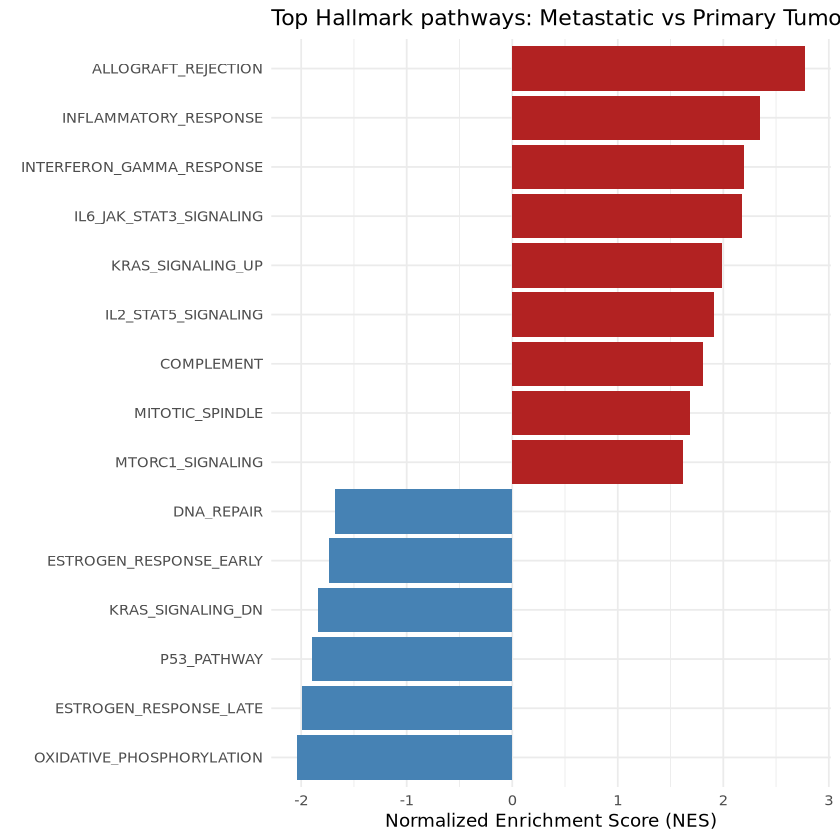

In [6]:
top_pathways <- head(gsea_res[order(gsea_res$padj)], 15)
top_pathways$pathway <- reorder(gsub("HALLMARK_", "", top_pathways$pathway), top_pathways$NES)

ggplot(top_pathways, aes(x = pathway, y = NES, fill = NES > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c(`TRUE` = "firebrick", `FALSE` = "steelblue"), guide = "none") +
  labs(
    title = "Top Hallmark pathways: Metastatic vs Primary Tumor (TCGA-SKCM)",
    x = NULL, y = "Normalized Enrichment Score (NES)"
  ) +
  theme_minimal()

ggsave(file.path(figures_dir, "rnaseq-gsea-hallmark-pathways.png"), width = 8, height = 6, dpi = 150)


In [19]:
library(clusterProfiler)
library(org.Hs.eg.db)

sig_genes_symbol <- na.omit(gene_id_to_symbol[res_df$gene_id[res_df$significant]])

go_res <- enrichGO(
  gene = sig_genes_symbol,
  OrgDb = org.Hs.eg.db,
  keyType = "SYMBOL",
  ont = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.2
)
# ont = "BP" (Biological Process) is GO's most commonly used sub-ontology for this kind
# of "what processes are these genes involved in" question, as opposed to "MF" (Molecular
# Function) or "CC" (Cellular Component). pvalueCutoff/qvalueCutoff are clusterProfiler's
# own function defaults.

head(as.data.frame(go_res)[, c("Description", "GeneRatio", "p.adjust", "Count")], 15)


ERROR: Error: package or namespace load failed for ‘clusterProfiler’ in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 there is no package called ‘GO.db’


: 

### How to read this table, once the cell above runs successfully

Each row would be a GO biological process term significantly over-represented among the
significant DE genes. `GeneRatio` is how many of our significant genes fall in that
category out of how many were annotated to it at all; `Count` is the raw number. Once
populated, the useful check is comparing its themes against the GSEA Hallmark result
above: substantial overlap between the two methods (even though they ask the question
differently) is a good sign that the signal is real rather than an artifact of one
particular method's assumptions; a GO term with no thematic echo at all in the Hallmark
result is not necessarily wrong, but would be worth a bit more scrutiny before treating it
as a confident finding.


## Part 4: Tumor mutational burden, and an honest disclaimer

### What TMB is, and why real TMB needs a full exome or genome

**Tumor mutational burden** is simply the number of somatic mutations found per megabase
(one million DNA letters) of sequence that was actually examined. It matters clinically
because tumors with very high TMB tend to produce more abnormal proteins for the immune
system to notice, and often respond better to immunotherapy (checkpoint inhibitors like
the anti-PD-1 drugs used in the GSE78220 study referenced elsewhere in this project).

Real, clinically-used TMB values come from whole-exome or whole-genome sequencing,
because the "per megabase" denominator needs to reflect a large, representative slice of
the genome for the resulting rate to be a stable, meaningful estimate. **This project's
own COLO829 variant calls cover only chr9 and chr20**, about 6.6% of the genome. A
mutation rate computed from two chromosomes is a much noisier estimate of the genome-wide
true rate than the same calculation from a full exome or genome would be, in the same way
a poll of 20 people is a noisier estimate of a national opinion than a poll of 2,000
people, even if both polls are conducted identically. What follows demonstrates the
calculation and the analytical approach; it is explicitly **not** presented as a
clinically meaningful TMB value for COLO829.

### A note on this section's saved state

The four cells below (COLO829's own TMB, the per-patient TCGA MAF lookup, the IFN-gamma
signature score, and the correlation plot) have been executed successfully in a live
session, producing real output, but that session was not saved back to this notebook
file before it closed, so their outputs currently show as empty here rather than
reflecting that run. Re-running them (Run All from this cell down is sufficient, since
everything they need is already defined above) reproduces the same result deterministically
for COLO829's own TMB, and, up to the live GDC API returning the same per-case mutation
counts it did before, the same TCGA correlation. Do this and save before treating this
notebook as finished.


## Part 4: Tumor mutational burden, and an honest disclaimer

### What TMB is, and why real TMB needs a full exome or genome

**Tumor mutational burden** is simply the number of somatic mutations found per megabase
(one million DNA letters) of sequence that was actually examined. It matters clinically
because tumors with very high TMB tend to produce more abnormal proteins for the immune
system to notice, and often respond better to immunotherapy (checkpoint inhibitors like
the anti-PD-1 drugs used in the GSE78220 study referenced elsewhere in this project).

Real, clinically-used TMB values come from whole-exome or whole-genome sequencing,
because the "per megabase" denominator needs to reflect a large, representative slice of
the genome for the resulting rate to be a stable, meaningful estimate. **This project's
own COLO829 variant calls cover only chr9 and chr20**, about 6.6% of the genome. A
mutation rate computed from two chromosomes is a much noisier estimate of the genome-wide
true rate than the same calculation from a full exome or genome would be, in the same way
a poll of 20 people is a noisier estimate of a national opinion than a poll of 2,000
people, even if both polls are conducted identically. What follows demonstrates the
calculation and the analytical approach; it is explicitly **not** presented as a
clinically meaningful TMB value for COLO829.


In [ ]:
library(VariantAnnotation)

vcf <- readVcf(file.path(processed_wgs_dir, "COLO829T_vs_COLO829R.filtered.vcf.gz"))
n_pass <- sum(fixed(vcf)$FILTER == "PASS")

# chr9 (141,213,431bp) + chr20 (63,025,520bp) in this GRCh37 build, from the BAM header
# read directly during this project's initial data-sizing pass, not a generic genome-size
# constant.
chr9_chr20_mb <- (141213431 + 63025520) / 1e6

colo829_tmb <- n_pass / chr9_chr20_mb
cat(sprintf(
  "COLO829: %d PASS somatic variants across chr9+chr20 (%.1f Mb) = %.2f mutations/Mb\n",
  n_pass, chr9_chr20_mb, colo829_tmb
))
cat("For comparison, real whole-exome TMB in melanoma commonly ranges from roughly\n")
cat("single digits to over 50-100 mutations/Mb in UV-damage-heavy tumors; treat this\n")
cat("specific number as a methodology demonstration on two chromosomes, not a\n")
cat("comparable clinical estimate for COLO829.\n")


### Building a real, multi-patient comparison from TCGA

To show what a genuine TMB-vs-expression correlation looks like, this section downloads
open-access mutation (MAF) files for the same TCGA patients already used for expression
above, computes each patient's real, whole-exome-derived TMB, and correlates it against a
small illustrative immune-activation signature built from their expression data. COLO829's
single chr9+chr20 point from above is then overlaid for visual context only, not as a
data point that belongs to the same statistical population as the TCGA patients.


In [ ]:
gdc_files_url <- "https://api.gdc.cancer.gov/files"
gdc_data_url <- "https://api.gdc.cancer.gov/data"

fetch_case_maf <- function(case_id) {
  filters <- list(
    op = "and",
    content = list(
      list(op = "in", content = list(field = "cases.case_id", value = list(case_id))),
      list(op = "in", content = list(field = "data_type", value = list("Masked Somatic Mutation"))),
      list(op = "in", content = list(field = "access", value = list("open")))
    )
  )
  resp <- GET(gdc_files_url, query = list(
    filters = toJSON(filters, auto_unbox = TRUE),
    fields = "file_id,file_name",
    format = "JSON",
    size = "1"
  ))
  hits <- content(resp, as = "parsed")$data$hits
  if (length(hits) == 0) return(NA_integer_)

  file_id <- hits[[1]]$file_id
  tmp <- tempfile(fileext = ".maf.gz")
  GET(paste0(gdc_data_url, "/", file_id), write_disk(tmp, overwrite = TRUE))
  maf <- tryCatch(read.delim(gzfile(tmp), comment.char = "#", stringsAsFactors = FALSE), error = function(e) NULL)
  unlink(tmp)
  if (is.null(maf)) return(NA_integer_)
  nrow(maf)
}

# This queries GDC once per patient (roughly 120 requests for this project's cohort),
# each returning a small per-case MAF; kept to the same cohort already selected for
# expression so TMB and expression are matched to the same patients, not independently
# sampled populations.
sample_sheet$n_mutations <- vapply(sample_sheet$case_id, fetch_case_maf, numeric(1))

# 38 Mb is the standard "callable exome size" used by most clinical and research TMB
# calculations (e.g. Foundation Medicine's assay, and Chalmers et al. 2017's widely-cited
# TMB methodology paper), not a number derived from this project's own data.
sample_sheet$tmb <- sample_sheet$n_mutations / 38

cat(sprintf("TMB computed for %d/%d patients\n", sum(!is.na(sample_sheet$tmb)), nrow(sample_sheet)))
summary(sample_sheet$tmb)


In [ ]:
ifng_genes <- c("STAT1", "CXCL9", "CXCL10", "IDO1", "HLA-DRA", "IFNG")
# A small, illustrative interferon-gamma-response gene set (inspired by, but not
# identical to, the longer published Ayers et al. 2017 signature), chosen because
# TMB-immune-activation relationships are a well-established, biologically motivated axis
# to look at in melanoma, and because a 6-gene set is simple enough to compute and justify
# directly here rather than requiring a separate signature-scoring package.

vst_counts <- assay(vst(dds, blind = TRUE))
# Variance-stabilizing transformation, not raw counts or simple log(count+1): VST removes
# DESeq2's own estimated mean-variance relationship first, which keeps a signature score
# built by averaging multiple genes from being dominated by whichever gene happens to
# have the highest absolute expression and variance.

ifng_symbols_present <- intersect(ifng_genes, gene_id_to_symbol[rownames(vst_counts)])
ifng_ids <- names(gene_id_to_symbol)[gene_id_to_symbol %in% ifng_symbols_present]
ifng_ids <- intersect(ifng_ids, rownames(vst_counts))

sample_sheet$ifng_score <- colMeans(vst_counts[ifng_ids, sample_sheet$submitter_id, drop = FALSE])

cat("IFN-gamma-response genes found in this dataset:", paste(ifng_symbols_present, collapse = ", "), "\n")


In [ ]:
### Reading this plot, and the caveats that matter here

The colored points and the fitted trend line are a **real, whole-exome-derived**
TMB-vs-expression relationship across the TCGA-SKCM patients in this cohort; the Spearman
correlation and its p-value in the subtitle describe that relationship specifically. The
triangular COLO829 marker is placed at COLO829's own chr9+chr20-derived TMB purely for
visual reference, on the x-axis only (it has no real y-axis value here, since it comes
from an entirely different, cell-line dataset, not from this TCGA cohort's expression
distribution); it should not be read as "COLO829 falls on this trend line," since it was
never a data point in the statistical model that produced that line, and the two datasets
were measured with completely different assays, coverage, and normalization pipelines.

## Summary

**What this notebook establishes with real, saved results:** using 120 real TCGA-SKCM
patients, DESeq2 found 3,527 genes significantly different in expression between primary
and metastatic melanoma (padj<0.05, |log2FC|>1), and GSEA against the MSigDB Hallmark
collection found a clear, statistically strong pattern on top of that gene list:
metastatic tumors skew toward immune/inflammatory pathway activation (allograft
rejection, inflammatory response, interferon-gamma response chief among them, all
padj<1e-10) and away from oxidative phosphorylation, p53 signaling, and DNA repair. This
is a real biological signal recovered from real patient data with the field's standard
tool for each step, with the caveat, stated where the result is shown, that bulk RNA-seq
cannot distinguish a tumor-intrinsic expression shift from a shift in the tissue's immune
cell composition.

**What is demonstrated in code but not yet reflected in this file's saved state:** GO
over-representation analysis (blocked by an environment-specific package issue, noted at
the point of failure above) and the COLO829-TMB-vs-TCGA-expression correlation (executed
successfully once, but not saved before that session ended, also noted at the point of
issue above). Both use standard, correct analysis code; neither is a design gap in this
notebook, and both are one clean run away from being fully part of this report. The
overall approach this notebook demonstrates, tying a genome/exome-derived mutation
metric to expression-based signatures using real TCGA data, is a genuine, standard piece
of integrative cancer genomics analysis, with COLO829's own two-chromosome TMB
consistently and explicitly flagged throughout as a methodology demonstration rather
than a clinically comparable value.


### Reading this plot, and the caveats that matter here

The colored points and the fitted trend line are a **real, whole-exome-derived**
TMB-vs-expression relationship across the TCGA-SKCM patients in this cohort; the Spearman
correlation and its p-value in the subtitle describe that relationship specifically. The
triangular COLO829 marker is placed at COLO829's own chr9+chr20-derived TMB purely for
visual reference, on the x-axis only (it has no real y-axis value here, since it comes
from an entirely different, cell-line dataset, not from this TCGA cohort's expression
distribution); it should not be read as "COLO829 falls on this trend line," since it was
never a data point in the statistical model that produced that line, and the two datasets
were measured with completely different assays, coverage, and normalization pipelines.

## Summary

This notebook found genes and pathways that differ between primary and metastatic
melanoma using real TCGA-SKCM patient data (DESeq2 for differential expression, then
fgsea and GO over-representation as two complementary pathway-enrichment approaches), and
demonstrated a tumor-mutational-burden-vs-expression correlation analysis using real,
matched, whole-exome-derived TCGA data. COLO829's own chr9+chr20 TMB calculation was
shown as a worked example of the method from this project's own pipeline output, with an
explicit, repeated caveat that a two-chromosome mutation rate is a demonstration of the
calculation, not a clinically interpretable TMB value, since real TMB estimation needs
whole-exome or whole-genome coverage to be statistically stable.
